### Transformation of Feature
Feature transformation means changing the scale, distribution, or form of a feature to make it more suitable for a machine learning model.
Esspecially required for linear  nad logistaic regression ---> for gradient descent--(global minima)  
Algorithm like KNN, k means , Hierarichal clustering  --->Eucledian Distance
#### why it needed:
It’s needed because raw data is rarely model-friendly.
1. To make data closer to a normal distribution.
   Real-world data is often skewed
3. To improve model performance.
   Transformation balances feature influence
4. To handle outliers
5. To satisfy algorithm requirements
6. To create linear relationships.
7. To speed up model training.
8. To speed up model training.


### For Deep Learning:(required Transformation)
1. ANN    --->Global Minima, Gradient
2. CNN
3. RNN

### Types of Transformation: 
1. Normalization and Standardization
2. Scaling to minimum and Maximum
3. scaling to  Median and Quartiles
4. Gaussian Transformation
    1. log transformation
    2. reciprocal transformation
    3. Square root transformation
    4. exponential transformation
    5. Box Cox transformation

### 1. Standardization
Standardization is a feature-scaling technique where numerical data is transformed so that it has mean = 0 and standard deviation = 1.
Why Standardization is Needed: 
1. Different features have different units.
2. Improves model performance.
3. Prevents bias
4. Faster convergence

Required For :
1. regression, k-means, KNN, SVM, PCA, Neural Network

Not required for:
Decision Trees , Random Forest , XGBoost
(They split based on rules, not distance)

In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [38]:
df=pd.read_csv('titanic.csv',usecols=['Pclass','Age','Fare','Survived'])

In [39]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [40]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [41]:
columns=df.columns
columns

Index(['Survived', 'Pclass', 'Age', 'Fare'], dtype='object')

In [42]:
df['Age'] =df["Age"].fillna(df['Age'].median())

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [44]:
stand_scaler_df=scaler.fit_transform(df)

In [45]:
stand_scaler_df=pd.DataFrame(stand_scaler_df)

In [46]:
stand_scaler_df.columns=columns

In [47]:
stand_scaler_df.head()

,Survived,Pclass,Age,Fare
0,-0.789272,0.827377,-0.565736,-0.502445
1,1.266990,-1.566107,0.663861,0.786845
2,1.266990,0.827377,-0.258337,-0.488854
3,1.266990,-1.566107,0.433312,0.420730
4,-0.789272,0.827377,0.433312,-0.486337


(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([-1.56610693, -1.44643272, -1.32675851, -1.2070843 , -1.08741009,
        -0.96773588, -0.84806167, -0.72838747, -0.60871326, -0.48903905,
        -0.36936484, -0.24969063, -0.13001642, -0.01034222,  0.10933199,
         0.2290062 ,  0.34868041,  0.46835462,  0.58802883,  0.70770304,
         0.82737724]),
 <BarContainer object of 20 artists>)

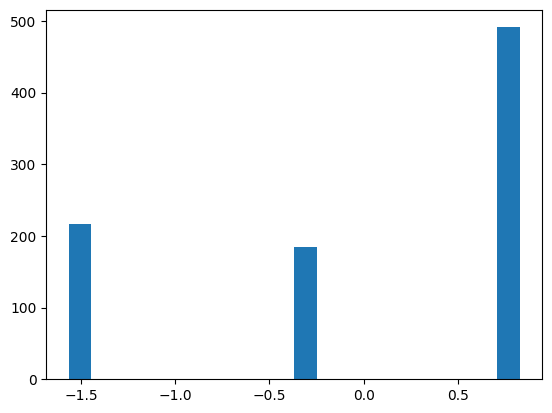

In [48]:
plt.hist(stand_scaler_df.iloc[:,1],bins=20)

(array([ 40.,  14.,  15.,  31.,  79.,  98., 262.,  84.,  73.,  45.,  35.,
         35.,  29.,  16.,  13.,  11.,   4.,   5.,   1.,   1.]),
 array([-2.22415608, -1.91837055, -1.61258503, -1.3067995 , -1.00101397,
        -0.69522845, -0.38944292, -0.08365739,  0.22212813,  0.52791366,
         0.83369919,  1.13948471,  1.44527024,  1.75105577,  2.05684129,
         2.36262682,  2.66841235,  2.97419787,  3.2799834 ,  3.58576892,
         3.89155445]),
 <BarContainer object of 20 artists>)

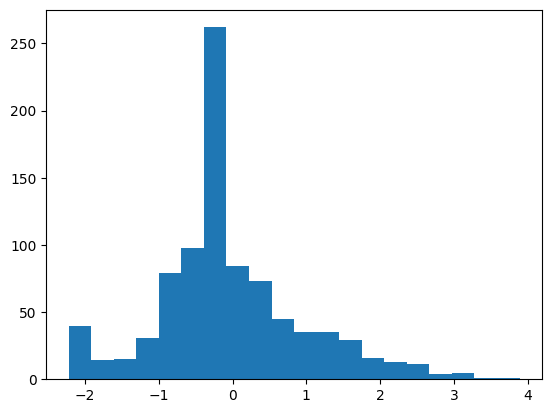

In [49]:
plt.hist(stand_scaler_df['Age'],bins=20)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.64842165, -0.13264224,  0.38313716,  0.89891657,  1.41469598,
         1.93047539,  2.4462548 ,  2.96203421,  3.47781362,  3.99359303,
         4.50937244,  5.02515184,  5.54093125,  6.05671066,  6.57249007,
         7.08826948,  7.60404889,  8.1198283 ,  8.63560771,  9.15138712,
         9.66716653]),
 <BarContainer object of 20 artists>)

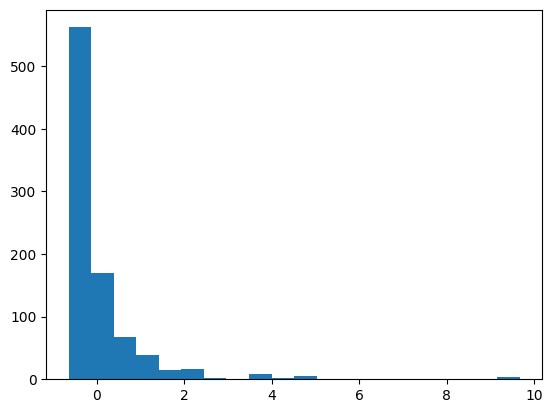

In [50]:
plt.hist(stand_scaler_df.iloc[:,3],bins=20)

In [51]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()

In [55]:
min_max_scaler_df =minmax.fit_transform(df)

In [59]:
min_max_scaler_df=pd.DataFrame(min_max_scaler_df)

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

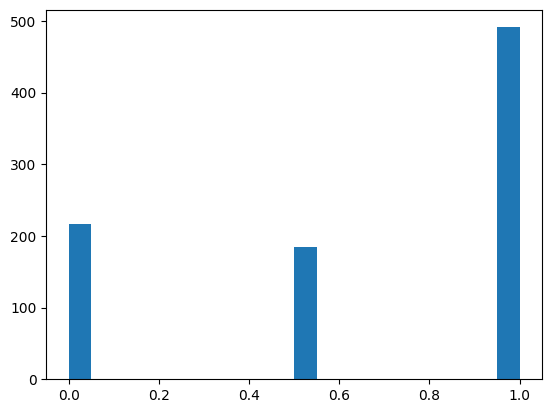

In [60]:
plt.hist(min_max_scaler_df.iloc[:,1],bins=20)

(array([ 40.,  14.,  15.,  31.,  79.,  98., 262.,  84.,  73.,  45.,  35.,
         35.,  29.,  16.,  13.,  11.,   4.,   5.,   1.,   1.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

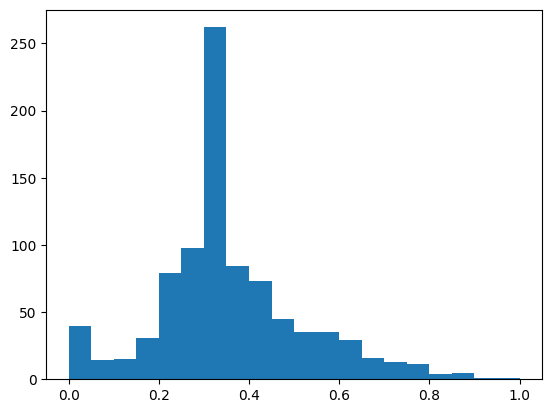

In [61]:
plt.hist(min_max_scaler_df.iloc[:,2],bins=20)

In [62]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()

In [63]:
scaler.fit_transform(df)

array([[ 0.        ,  0.        , -0.46153846, -0.3120106 ],
       [ 1.        , -2.        ,  0.76923077,  2.46124229],
       [ 1.        ,  0.        , -0.15384615, -0.28277666],
       ...,
       [ 0.        ,  0.        ,  0.        ,  0.38960398],
       [ 1.        , -2.        , -0.15384615,  0.67328148],
       [ 0.        ,  0.        ,  0.30769231, -0.29035583]],
      shape=(891, 4))

In [84]:
# QQ plot 
import scipy.stats as stats
import pylab
def plot(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stats.probplot(df[feature],dist="norm",plot=pylab)
    plt.show()

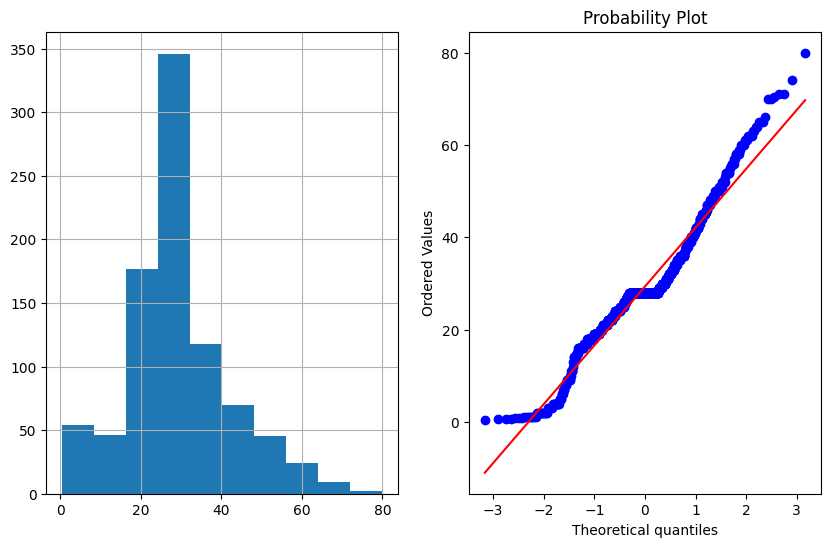

In [85]:
plot(df,'Age')